In [28]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("supermarket_sales.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [29]:
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


In [30]:
df.shape #Finding the size of the dataset.

(1000, 17)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [32]:
df.isnull().sum() #Checking for missing values

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [33]:
df.duplicated().sum() #Checking for duplicates

np.int64(0)

In [34]:
df['Date']=pd.to_datetime(df['Date']) #Converting date column from text format to datetime format.

In [35]:
df["Date"].dtype

dtype('<M8[ns]')

In [36]:
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M").dt.hour #Extracting the hour from the time column.

In [37]:
df[["Time", "Hour"]].head()

,Time,Hour
0,13:08,13
1,10:29,10
2,13:23,13
3,20:33,20
4,10:37,10


In [38]:
df.describe().round(2)

,Unit price,Quantity,Tax 5%,Total,Date,cogs,gross margin percentage,gross income,Rating,Hour
count,1000.00,1000.00,1000.00,1000.00,1000,1000.00,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,15.38,322.97,2019-02-14 00:05:45.600000,307.59,4.76,15.38,6.97,14.91
min,10.08,1.00,0.51,10.68,2019-01-01 00:00:00,10.17,4.76,0.51,4.00,10.00
25%,32.88,3.00,5.92,124.42,2019-01-24 00:00:00,118.50,4.76,5.92,5.50,12.00
50%,55.23,5.00,12.09,253.85,2019-02-13 00:00:00,241.76,4.76,12.09,7.00,15.00
75%,77.94,8.00,22.45,471.35,2019-03-08 00:00:00,448.90,4.76,22.45,8.50,18.00
max,99.96,10.00,49.65,1042.65,2019-03-30 00:00:00,993.00,4.76,49.65,10.00,20.00
std,26.49,2.92,11.71,245.89,NaN,234.18,0.00,11.71,1.72,3.19


In [39]:
#Calculating total sales and order count for each branch. This allows to compare the overall sales performance of Branch A, B, and C.
branch_analysis = (df.groupby('Branch').agg(total_sales = ('Total', 'sum'), order_count = ('Invoice ID','count')).sort_values('total_sales', ascending = False))

In [40]:
print(branch_analysis)

        total_sales  order_count
Branch                          
C       110568.7065          328
A       106200.3705          340
B       106197.6720          332


In [41]:
#Calculating total sales and order count for each product line. This helps identify the highest and lowest revenue-generating categories.
product_analysis = (df.groupby('Product line').agg( total_sales = ('Total', 'sum'), order_count = ('Invoice ID', 'count')).sort_values('total_sales', ascending = False))
print(product_analysis)

                        total_sales  order_count
Product line                                    
Food and beverages       56144.8440          174
Sports and travel        55122.8265          166
Electronic accessories   54337.5315          170
Fashion accessories      54305.8950          178
Home and lifestyle       53861.9130          160
Health and beauty        49193.7390          152


In [42]:
#Calculating total sales and order count for each type of customer. This allows to compare the contribution of the customer groups.
customer_analysis = (df.groupby('Customer type').agg( total_sales = ('Total', 'sum'), order_count = ('Invoice ID', 'count')).sort_values('total_sales', ascending = False))
print(customer_analysis)

               total_sales  order_count
Customer type                          
Member          164223.444          501
Normal          158743.305          499


In [43]:
# Calculating total sales and order count by gender.This helps compare purchasing behavior between female and male customers.
gender_analysis = (df.groupby('Gender').agg( total_sales = ('Total', 'sum'), order_count = ('Invoice ID', 'count')).sort_values('total_sales', ascending = False))
print(gender_analysis)

        total_sales  order_count
Gender                          
Female   167882.925          501
Male     155083.824          499


In [44]:
#Aggregating total sales by hour of the day.
hourly_sales = (df.groupby('Hour')['Total'].sum().sort_index())
hourly_sales

Hour
10    31421.4810
11    30377.3295
12    26065.8825
13    34723.2270
14    30828.3990
15    31179.5085
16    25226.3235
17    24445.2180
18    26030.3400
19    39699.5130
20    22969.5270
Name: Total, dtype: float64

In [45]:
# Identifying the hour with the highest total sales with this we can determine peak sales period of the day.
busiest_hour = hourly_sales.idxmax()
busiest_sales = hourly_sales.max()

print('Busiest Hour:', busiest_hour)
print('Sales:', busiest_sales)

Busiest Hour: 19
Sales: 39699.513


In [46]:
# Calculating the average order value for each branch. This is going to help to determine whether the differrences in total sales are related to the number of orders.
branch_analysis['average_order_value'] = (branch_analysis['total_sales'] / branch_analysis['order_count'])
branch_analysis

,total_sales,order_count,average_order_value
Branch,,,
C,110568.7065,328,337.099715
A,106200.3705,340,312.354031
B,106197.6720,332,319.872506


In [47]:
# Calculating the average order value for each product line. This provides additional context because a product line can have high revenue due to many orders.
product_analysis['average_order_value'] = (product_analysis['total_sales'] / product_analysis['order_count'])
product_analysis

,total_sales,order_count,average_order_value
Product line,,,
Food and beverages,56144.8440,174,322.671517
Sports and travel,55122.8265,166,332.065220
Electronic accessories,54337.5315,170,319.632538
Fashion accessories,54305.8950,178,305.089298
Home and lifestyle,53861.9130,160,336.636956
Health and beauty,49193.7390,152,323.643020


In [48]:
# Calculating the average order value by gender.
gender_analysis["average_order_value"] = (gender_analysis['total_sales'] / gender_analysis['order_count'])
gender_analysis

,total_sales,order_count,average_order_value
Gender,,,
Female,167882.925,501,335.095659
Male,155083.824,499,310.789226


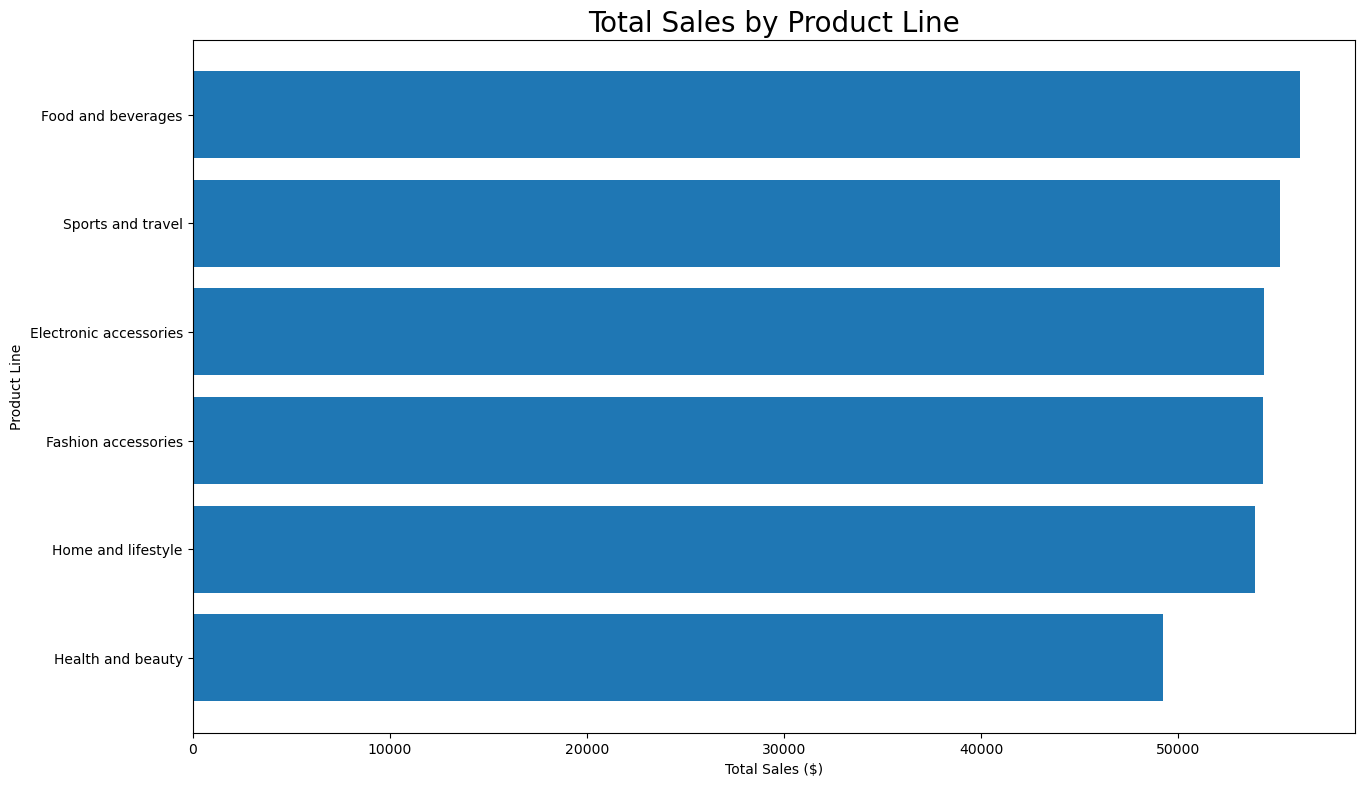

In [49]:
# Creating a horizontal bar chart to compare total sales across product lines.

plt.figure(figsize=(15, 9))

sales = product_analysis['total_sales'].sort_values()

plt.barh(sales.index, sales.values)

plt.title('Total Sales by Product Line', fontsize=20)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Line')
plt.savefig('total_sales_by_product_line', dpi=150)

plt.show()

The bar chart shows that **Food and beverages** generated the highest total sales, while **Health and beauty** generated the lowest.
Overall, the differences between product lines are relatively moderate, indicating that sales are distributed fairly evenly across categories.

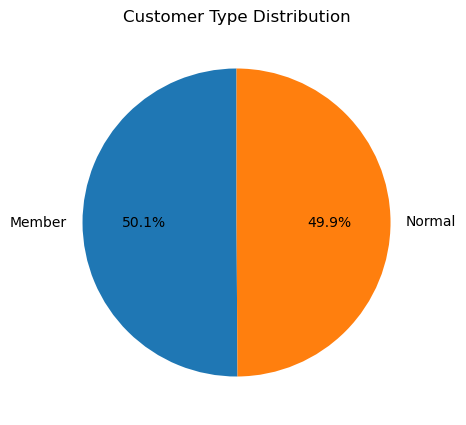

In [50]:
# Calculating the number of transactions for each customer type and creating a pie chart to visualize the proportion of Member and Normal customers.

customer_counts = df['Customer type'].value_counts()

plt.figure(figsize=(7, 5))

plt.pie( customer_counts, labels=customer_counts.index, autopct="%1.1f%%", startangle=90 )

plt.title('Customer Type Distribution')
plt.savefig('customer_type_distribution.png', dpi=150)

plt.show()

The customer distribution is almost evenly split between Members and Normal customers.
|
Members represent **50.1%** of transactions, while Normal customers represent **49.9%**.

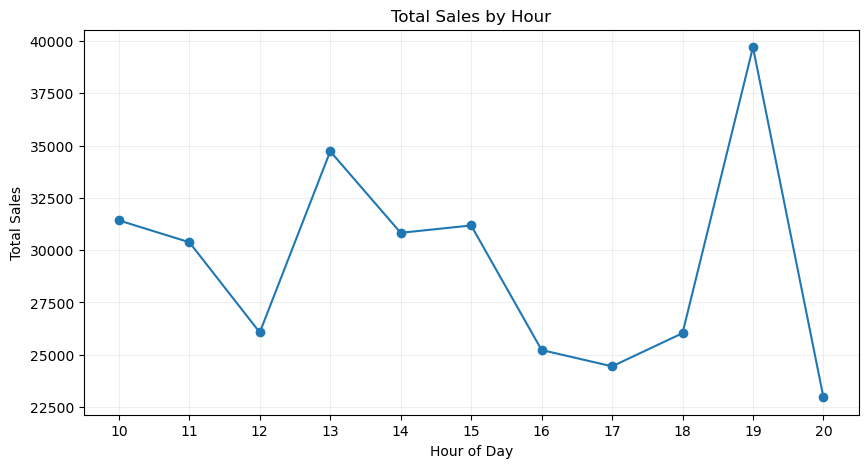

In [51]:
# Creating a line chart to visualize changes in total sales throughout the day. The hourly trend helps identify peak and low sales periods.

plt.figure(figsize=(10, 5))

plt.plot( hourly_sales.index, hourly_sales.values, marker="o")

plt.title('Total Sales by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales')
plt.xticks(range(10, 21))
plt.grid(True, alpha=0.2)
plt.savefig('total_sales_by_hour.png', dpi=150)
plt.show()

The hourly sales chart shows noticeable peaks around **13:00 and 19:00**.
The highest sales occur at **19:00**, making it the busiest sales period in the dataset.

In [52]:
# Calculating total sales and gross income for each product line and gross margin.

margin_analysis = (df.groupby('Product line').agg( total_sales=('Total', 'sum'), gross_income=('gross income', 'sum')))

margin_analysis['Gross_Margin_%'] = ( margin_analysis['gross_income'] / margin_analysis['total_sales'] * 100 )

margin_analysis.sort_values( 'Gross_Margin_%', ascending=False ).round(2)

,total_sales,gross_income,Gross_Margin_%
Product line,,,
Health and beauty,49193.74,2342.56,4.76
Electronic accessories,54337.53,2587.50,4.76
Fashion accessories,54305.90,2586.00,4.76
Food and beverages,56144.84,2673.56,4.76
Home and lifestyle,53861.91,2564.85,4.76
Sports and travel,55122.83,2624.90,4.76


The gross margin percentage is approximately **4.76% across all product lines**.

In [53]:
branch_product_sales = pd.pivot_table(df, values='Total', index='Branch', columns='Product line', aggfunc='sum').round(2)
branch_product_sales

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Branch,,,,,,
A,18317.11,16332.51,17163.10,12597.75,22417.20,19372.70
B,17051.44,16413.32,15214.89,19980.66,17549.16,19988.20
C,18968.97,21560.07,23766.86,16615.33,13895.55,15761.93


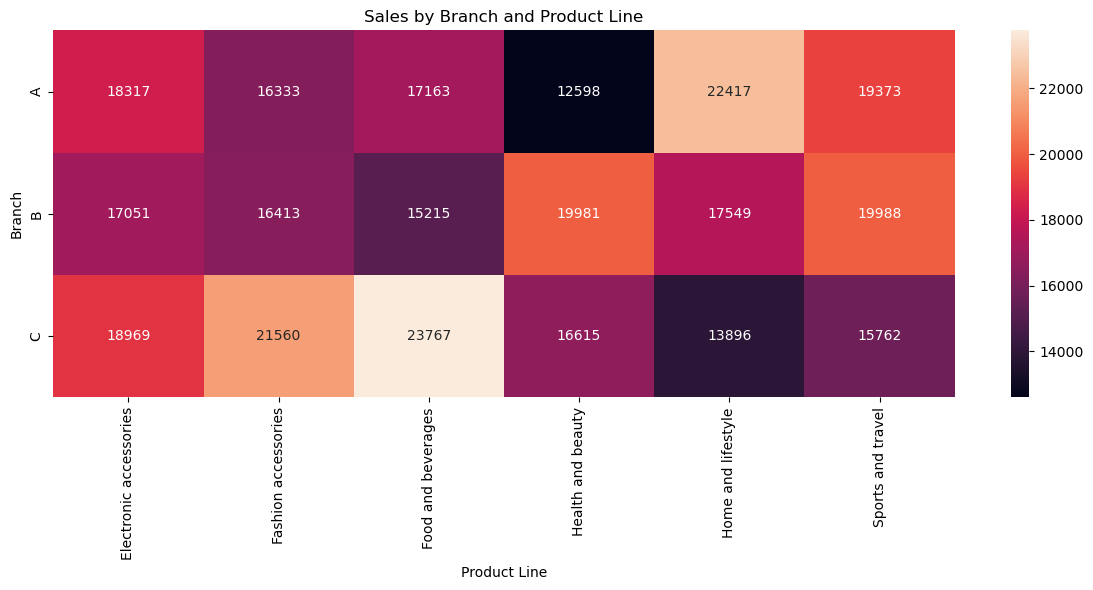

In [54]:
plt.figure(figsize=(12, 6))

sns.heatmap( branch_product_sales, annot=True, fmt=".0f" )

plt.title('Sales by Branch and Product Line')
plt.xlabel('Product Line')
plt.ylabel('Branch')
plt.tight_layout()
plt.savefig('sales_by_branch_and_product_line.png', dpi=150)
plt.show()


The highest Branch–Product Line combination is **Branch C and Food and beverages**, with approximately **$23.77K** in sales.

The lowest combination is **Branch A and Health and beauty**, with approximately **$12.60K**.

This suggests that customer demand for specific product categories differs between branches.

In [55]:
df['Month'] = df['Date'].dt.month

monthly_sales = (df.groupby('Month')['Total'].sum().sort_index())
monthly_sales

Month
1    116291.868
2     97219.374
3    109455.507
Name: Total, dtype: float64

In [56]:
# Calculating the overall average customer rating across all transactions. This provides a general measure of customer satisfaction in the dataset.
average_rating = df['Rating'].mean()
print('Average Rating:', round(average_rating, 2))

Average Rating: 6.97


In [57]:
# Calculating the average customer rating for each branch. This allows us to compare customer ratings across locations.
branch_rating = (df.groupby('Branch')['Rating'].mean().sort_values(ascending=False)).round(2)
branch_rating

Branch
C    7.07
A    7.03
B    6.82
Name: Rating, dtype: float64

The overall average customer rating is **6.97/10**.

Branch C has the highest average rating at **7.07**, followed by Branch A at **7.03** and Branch B at **6.82**.

The differences are relatively small, suggesting that customer ratings are generally consistent across branches.

In [58]:
df.to_csv('supermarket_sales_cleaned.csv', index=False)

# Business Insights

### **1. Focus on Branch C**

Branch C is the strongest branch by total sales and average order value. Management could study the practices, product mix, and customer behavior at Branch C and identify strategies that could be applied to the other branches.

### **2. Strengthen High-Performing Product Lines**

Food and beverages is the highest-revenue product line. The business could maintain strong stock availability for this category and consider promotions or product bundles to increase sales further.

### **3. Investigate Health and Beauty Performance**

Health and beauty has the lowest total sales and the lowest order count among the product lines. This category may benefit from additional promotion, improved product placement, or further analysis of customer demand.

### **4. Use Peak Hours for Promotions and Staffing**

The strongest sales period is around **19:00**, with another important peak around **13:00**. The business could align staffing and promotional activity with these periods to support customer demand and improve the shopping experience.

### **5. Encourage Higher-Value Purchases**

Home and lifestyle has the highest average order value, while Branch C also has the highest average order value overall. Similar products, bundles, or cross-selling strategies could be tested in other branches to increase transaction value.

### **6. Maintain Member Engagement**

Member and Normal customers are almost evenly distributed, but Members generate slightly more total sales. Loyalty programs and targeted member promotions could help increase repeat purchases and strengthen customer retention.

### **7. Improve the Lower-Rated Branch**

Branch B has the lowest average customer rating at approximately **6.82**. The business could investigate customer feedback, service quality, product availability, or other operational factors at this branch.

# Conclusion

The EDA shows that supermarket sales are relatively balanced across branches and customer groups, but there are meaningful differences in product performance, average order value, and sales timing.

**Branch C**, **Food and beverages**, and the **19:00 sales period** are the strongest areas identified in the analysis. At the same time, **Health and beauty** and **Branch B's customer rating** represent areas that could be investigated further.


In [59]:
#Bonus
branch_hourly_sales = (df.groupby(["Branch", "Hour"])["Total"].sum().reset_index())
branch_hourly_sales

,Branch,Hour,Total
0,A,10,11208.4140
1,A,11,11349.8910
2,A,12,9485.0700
3,A,13,10443.7515
4,A,14,8852.4135
5,A,15,11273.7030
6,A,16,10869.7365
7,A,17,9043.7340
8,A,18,7447.0200
9,A,19,10330.2570


In [60]:
# Finding the hour with the highest total sales for each branch
peak_hour_by_branch = (branch_hourly_sales.loc[branch_hourly_sales.groupby("Branch")["Total"].idxmax()])
peak_hour_by_branch

,Branch,Hour,Total
1,A,11,11349.8910
20,B,19,16262.4525
31,C,19,13106.8035


# Peak Sales Hour by Branch

- **Branch A:** The highest sales occurred at **11:00**, with approximately **USD 11.35K** in sales.
- **Branch B:** The highest sales occurred at **19:00**, with approximately **USD 16.26K** in sales.
- **Branch C:** The highest sales occurred at **19:00**, with approximately **USD 13.11K** in sales.

This shows that customer purchasing patterns vary across branches. Branch B and Branch C experience their highest sales in the evening, while Branch A reaches its peak around late morning.